# Sensor Timeseries

Laedt die Sensordaten und zeichnet fuer jeden Sensor eine Zeitreihe: `Time` auf der x-Achse, Sensorwert auf der y-Achse.

In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "output" / "Water_Pump_Dataset_for_a_Water_Supply_System" / "parser.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

mpl_config_dir = PROJECT_ROOT / ".matplotlib-cache"
mpl_config_dir.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(mpl_config_dir))

import matplotlib.pyplot as plt
from output.save.parser import parse

plt.style.use("default")
plt.rcParams["figure.figsize"] = (14, 3.5)
plt.rcParams["axes.grid"] = True

PROJECT_ROOT

Matplotlib is building the font cache; this may take a moment.


PosixPath('/Users/lars/Teco')

## Daten laden

The parser determines an appropriate observation frequency from the dataset when temporal regularization is required.

In [2]:
DATA_DIR = PROJECT_ROOT / "data"
ACTIVITY_ID_COL = "activity_id"
df = parse(str(DATA_DIR), ACTIVITY_ID_COL)

print("shape:", df.shape)
print("time range:", df.index.min(), "bis", df.index.max())
print("memory MB:", round(df.memory_usage(deep=True).sum() / 1024**2, 1))
df.head()

FileNotFoundError: No .txt files found in /Users/lars/Teco/data

## Sensor-Spalten

In [ ]:
sensor_cols = [col for col in df.columns if col != ACTIVITY_ID_COL]

print(f"{len(sensor_cols)} Sensor-Spalten gefunden")
pd.DataFrame({"sensor": sensor_cols})

72 Sensor-Spalten gefunden


,sensor
0,Current_Sensor_NeWater_Pump_1_power.i1
1,Current_Sensor_NeWater_Pump_1_power.i2
2,Current_Sensor_NeWater_Pump_1_power.i3
3,Current_Sensor_NeWater_Pump_2_power.i1
4,Current_Sensor_NeWater_Pump_2_power.i2
...,...
67,Vibration_Sensor_Potable_Pump_2_Y-Axis_Y_Speed...
68,Vibration_Sensor_Potable_Pump_2_Z-Axis_Displac...
69,Vibration_Sensor_Potable_Pump_2_Z-Axis_Speed_Z...
70,Water_Level_Sensor_NeWater_Tank_Water Level (mm)


## Alle Sensoren als Timeseries

Die Werte werden nur fuer die Darstellung geduennnt, damit das Notebook fluessig bleibt. Die Daten in `df` bleiben unveraendert.

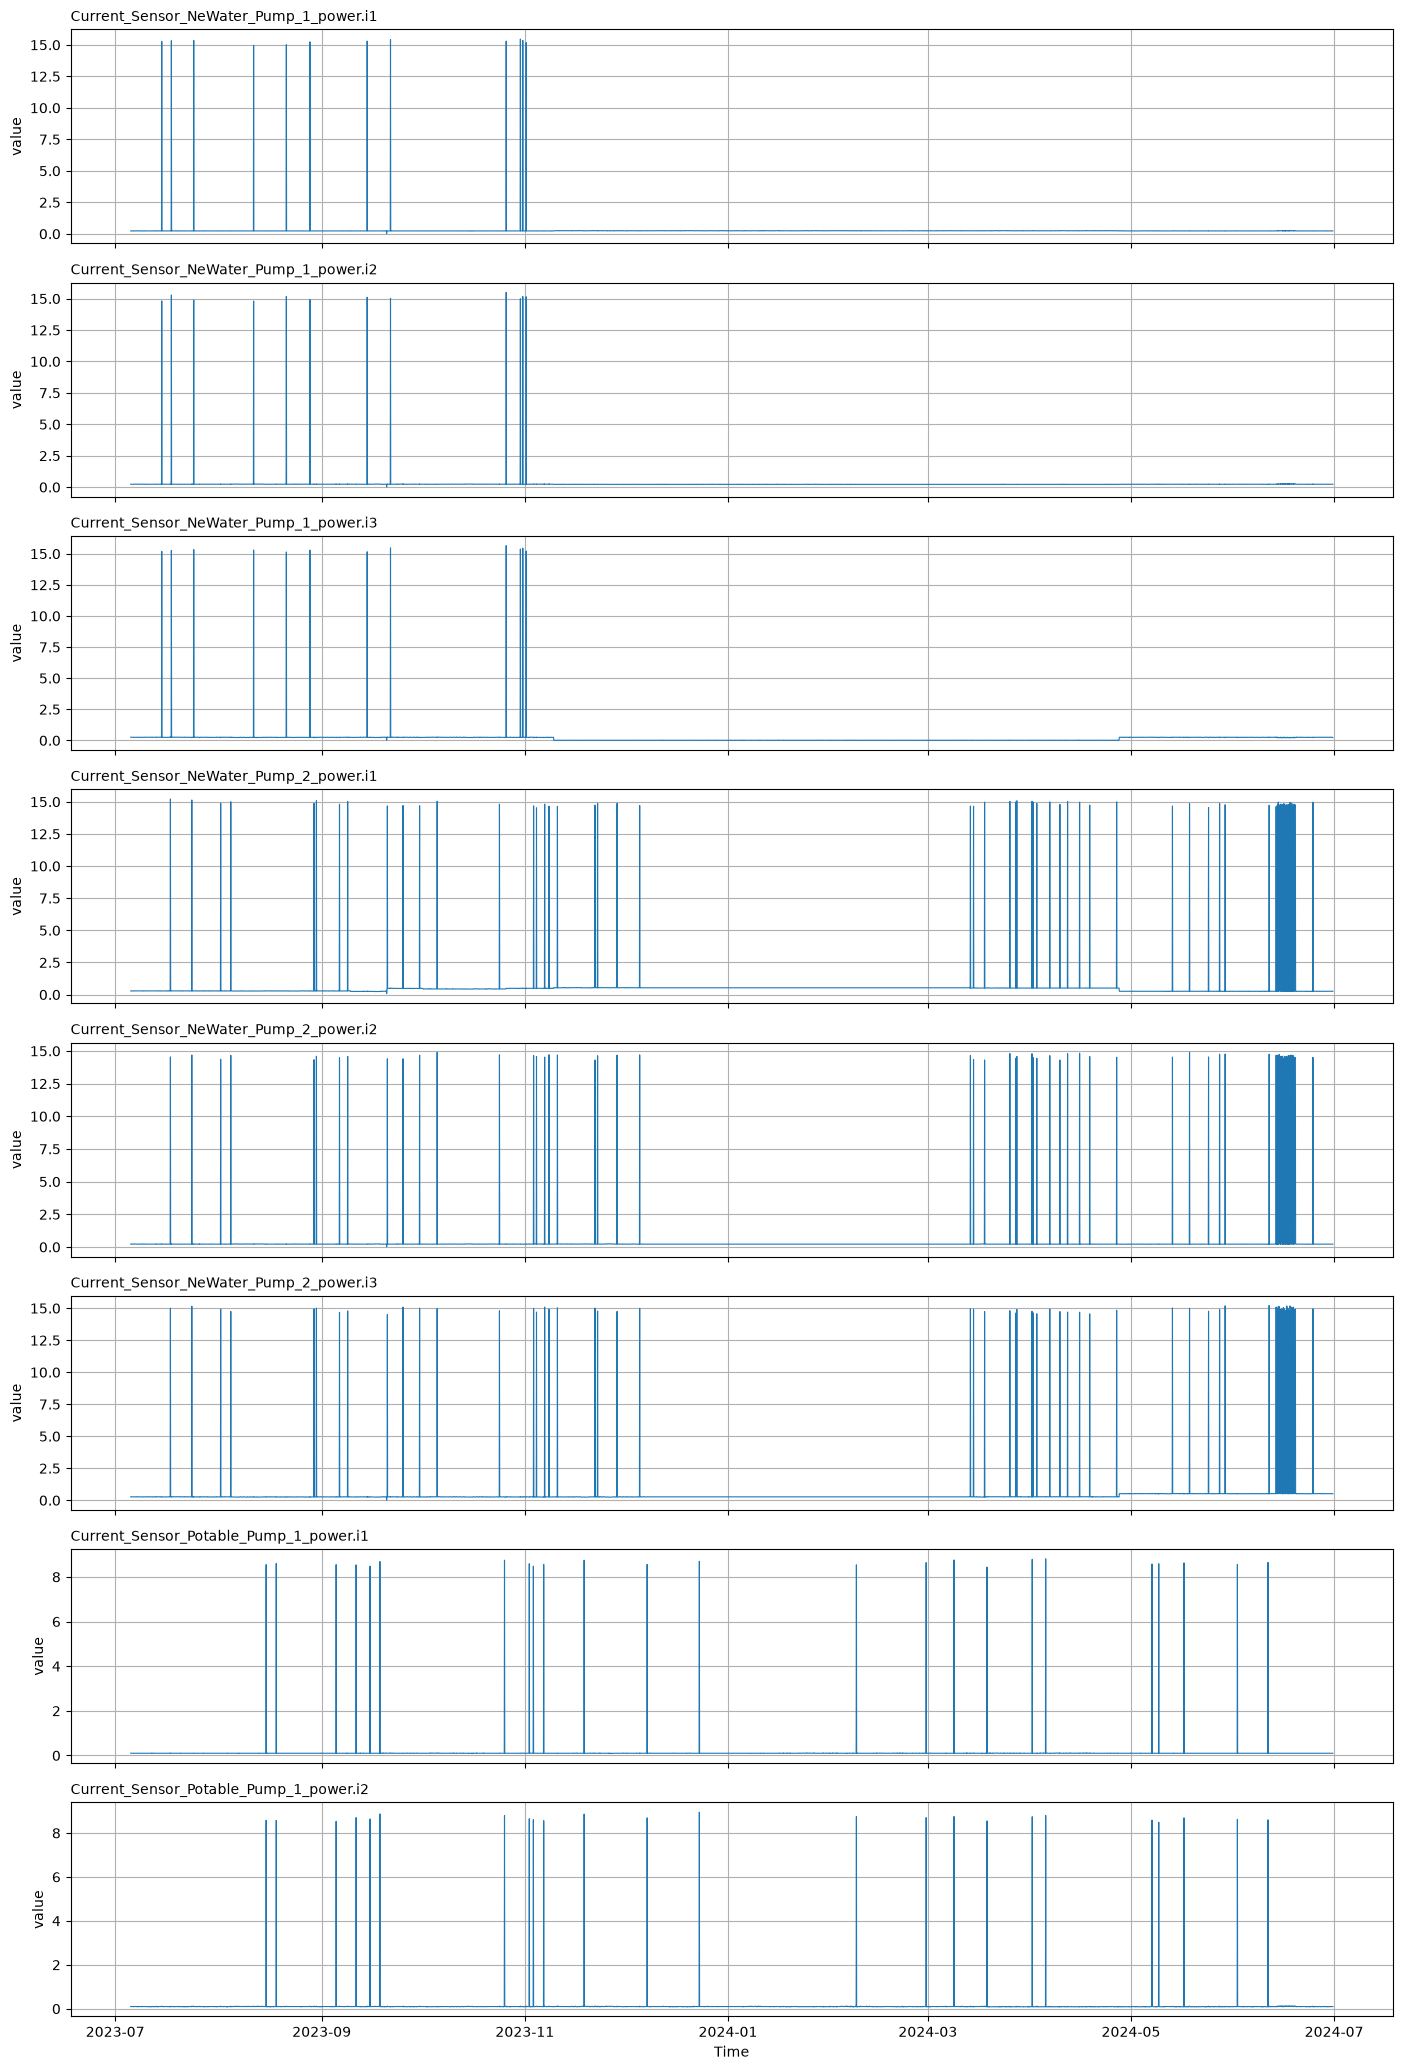

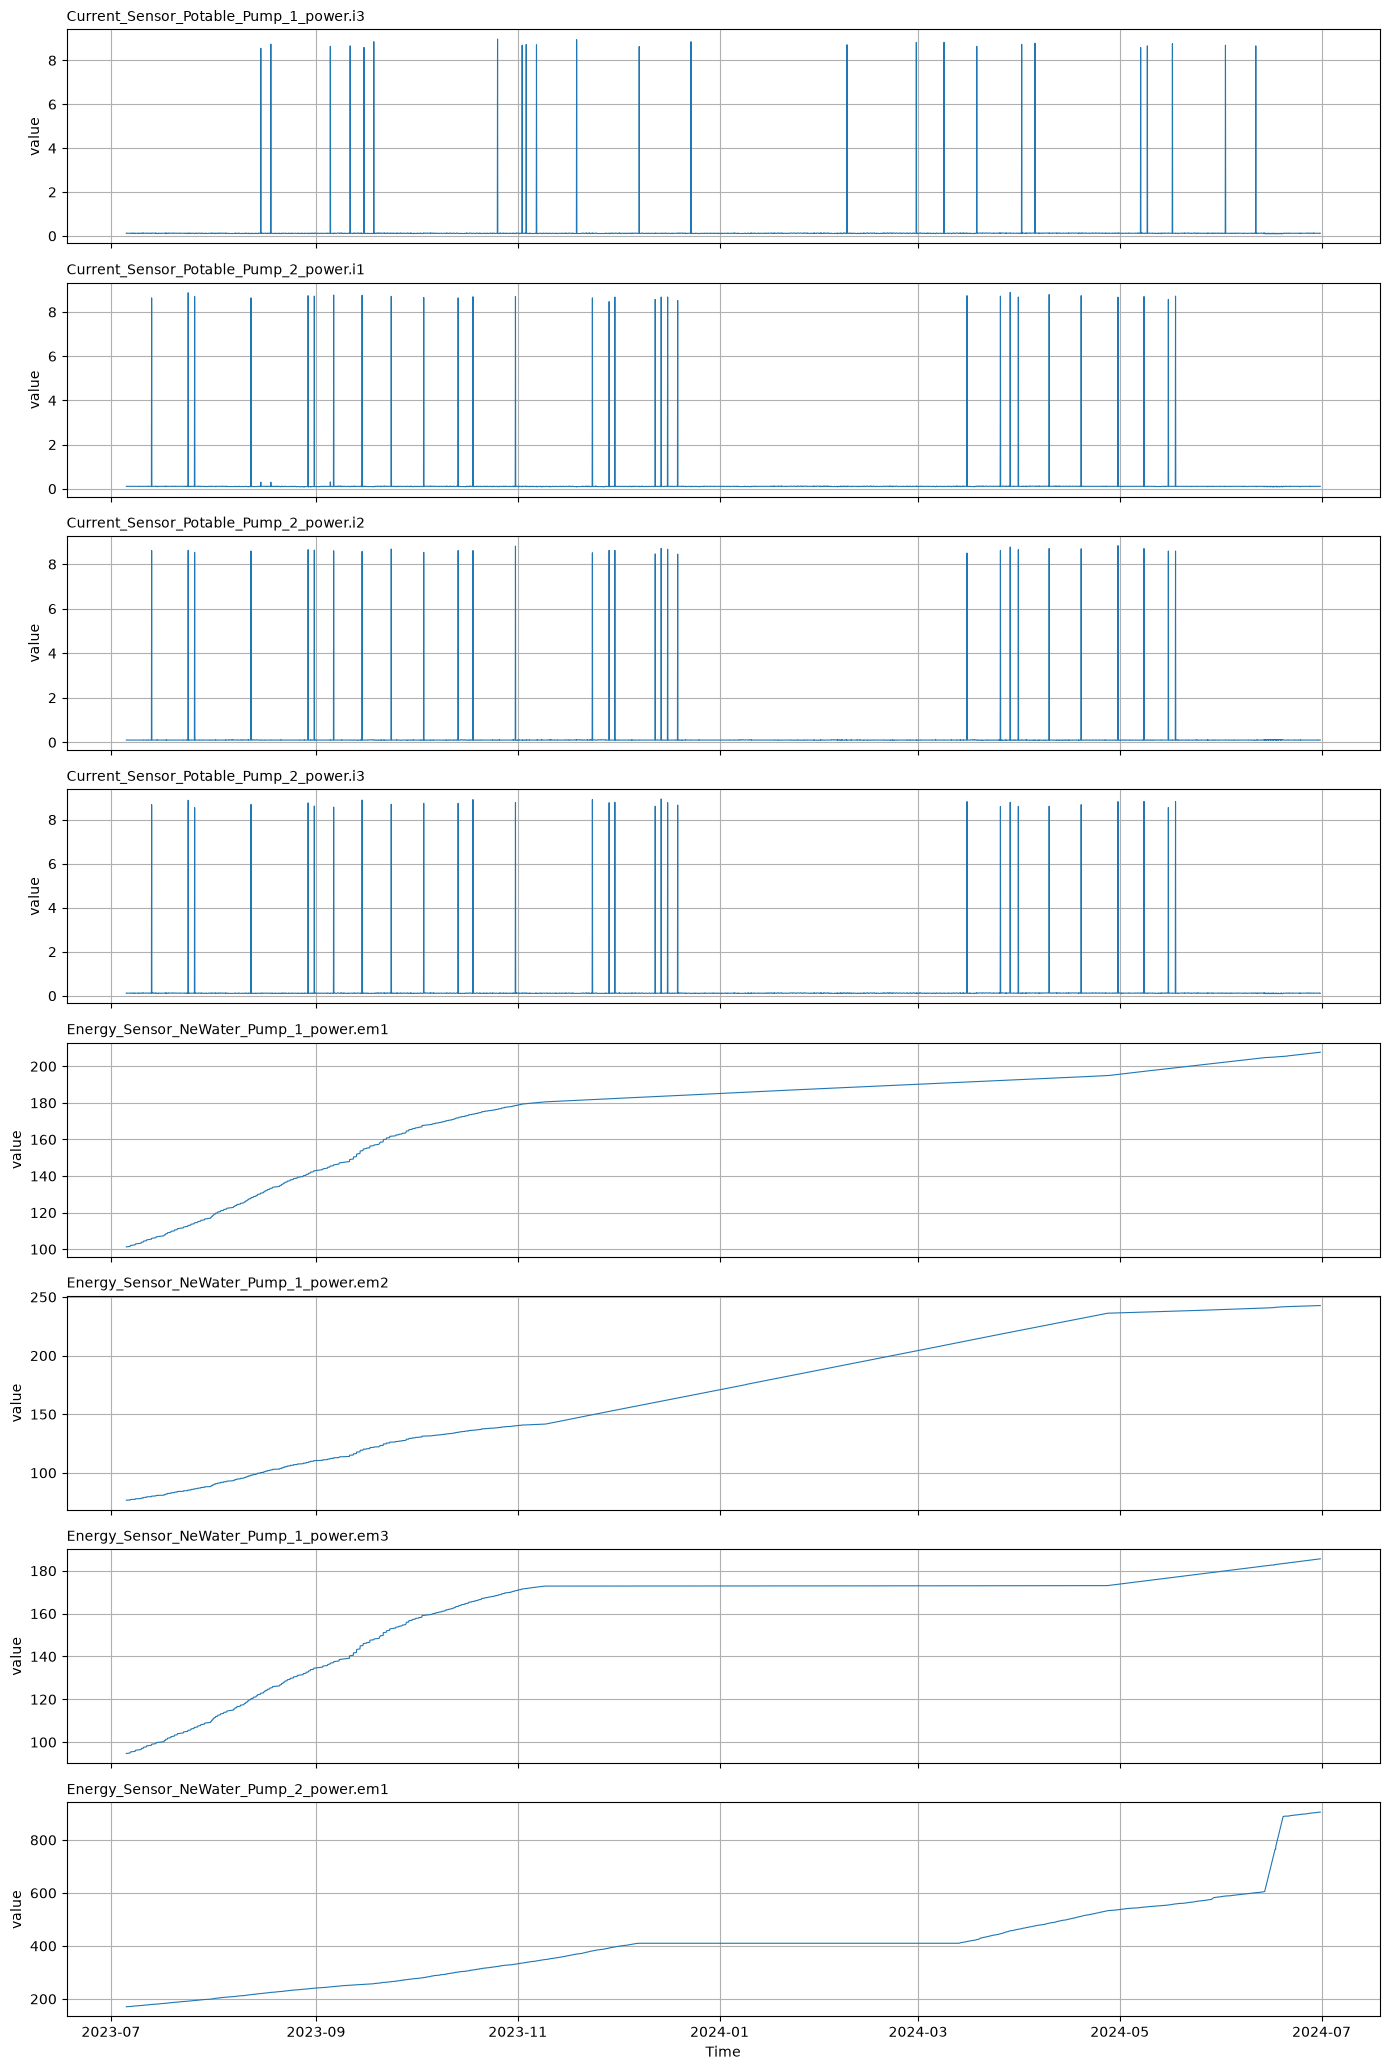

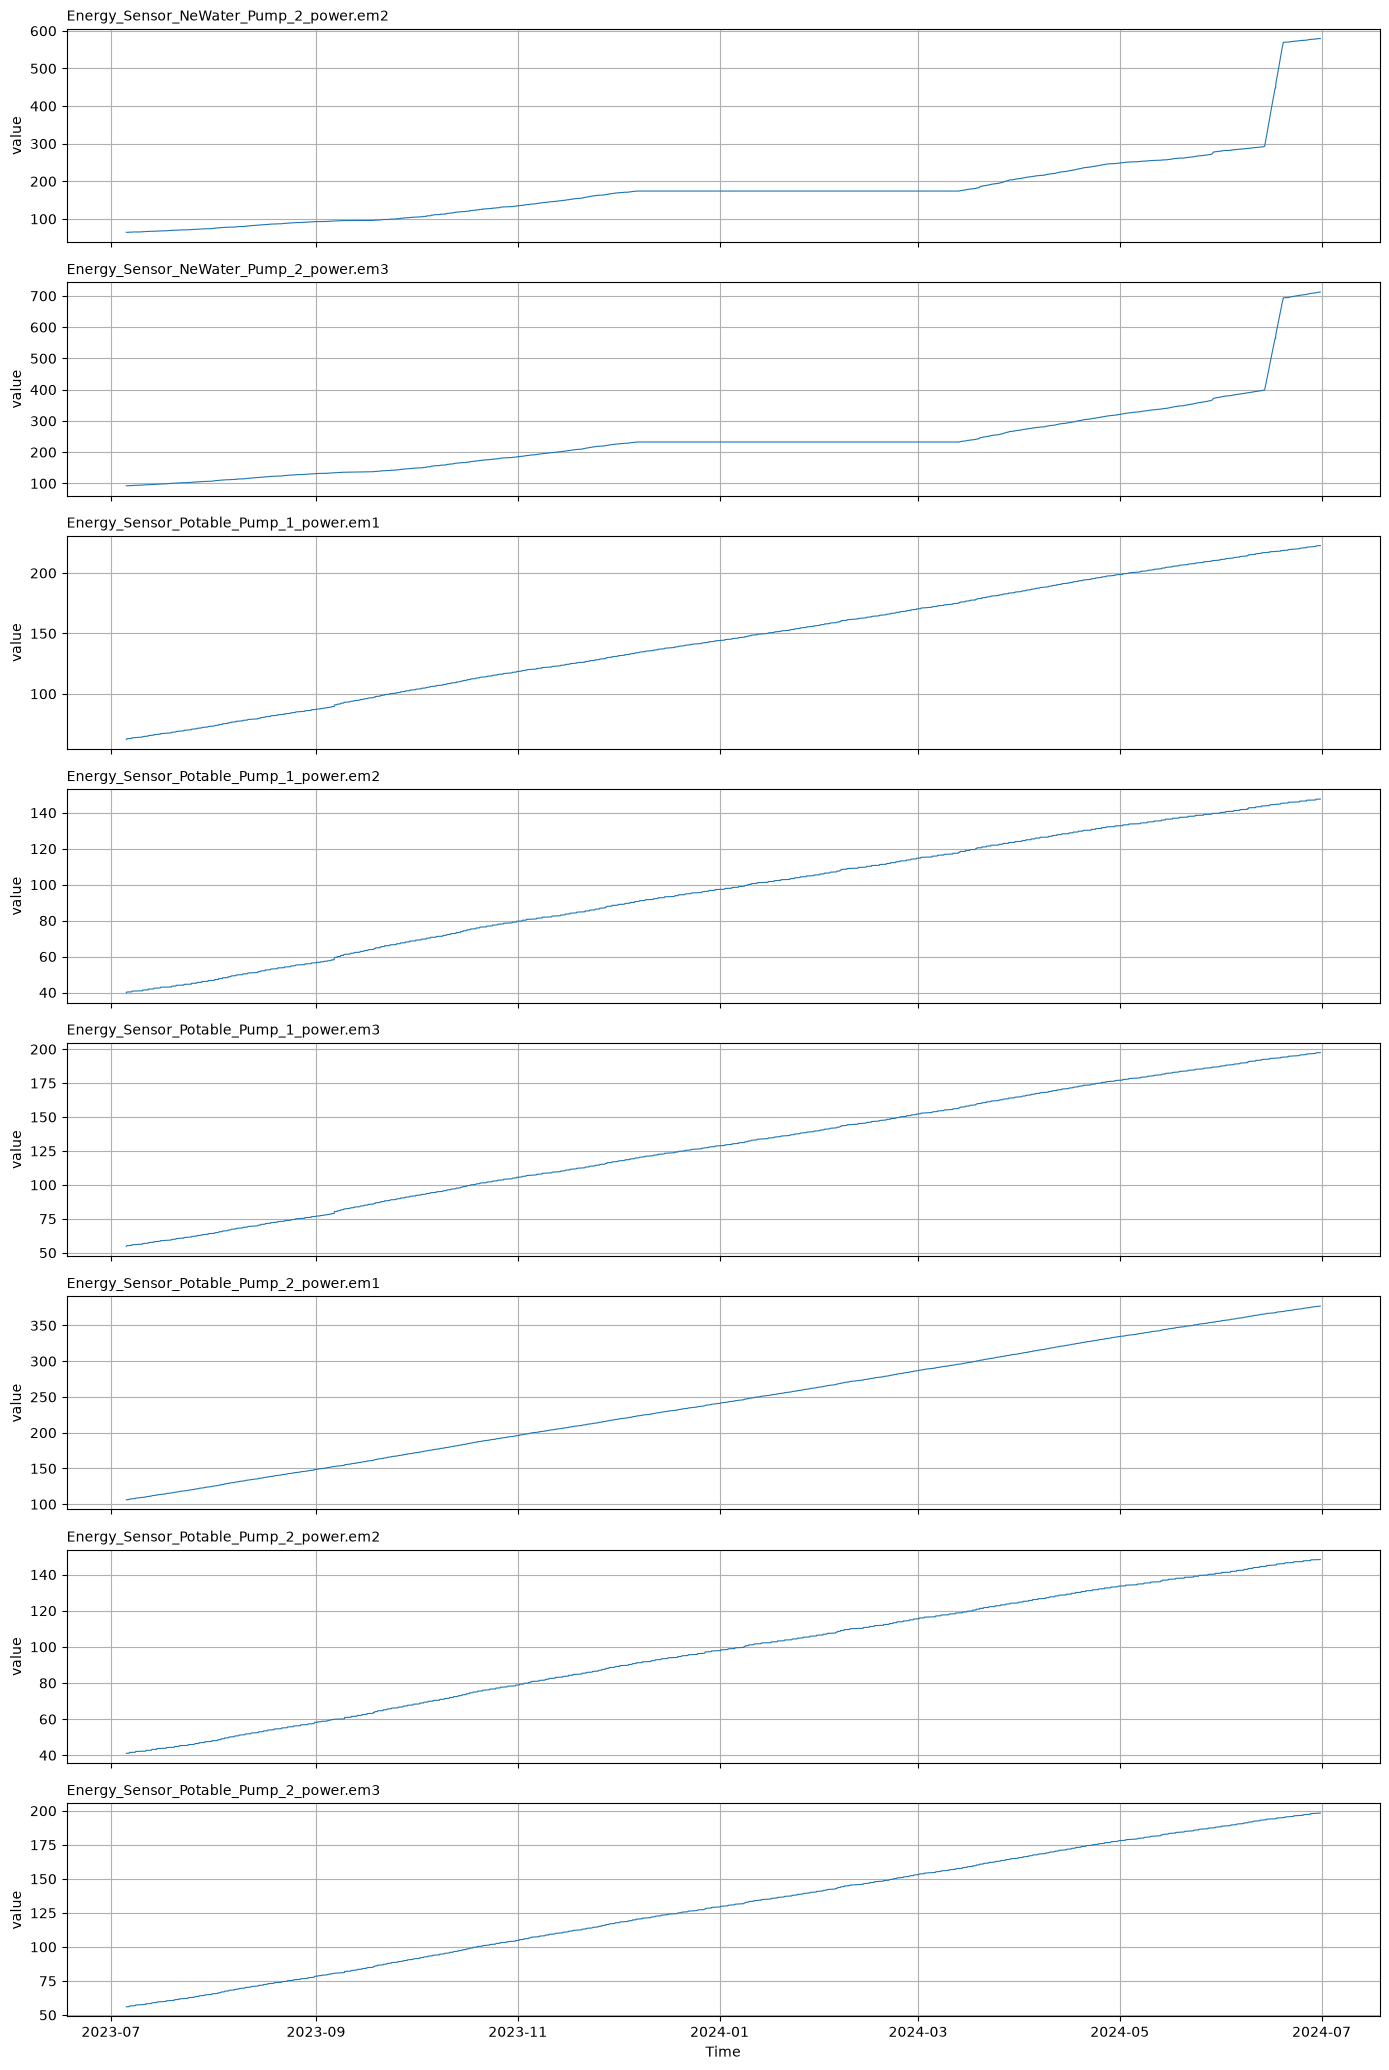

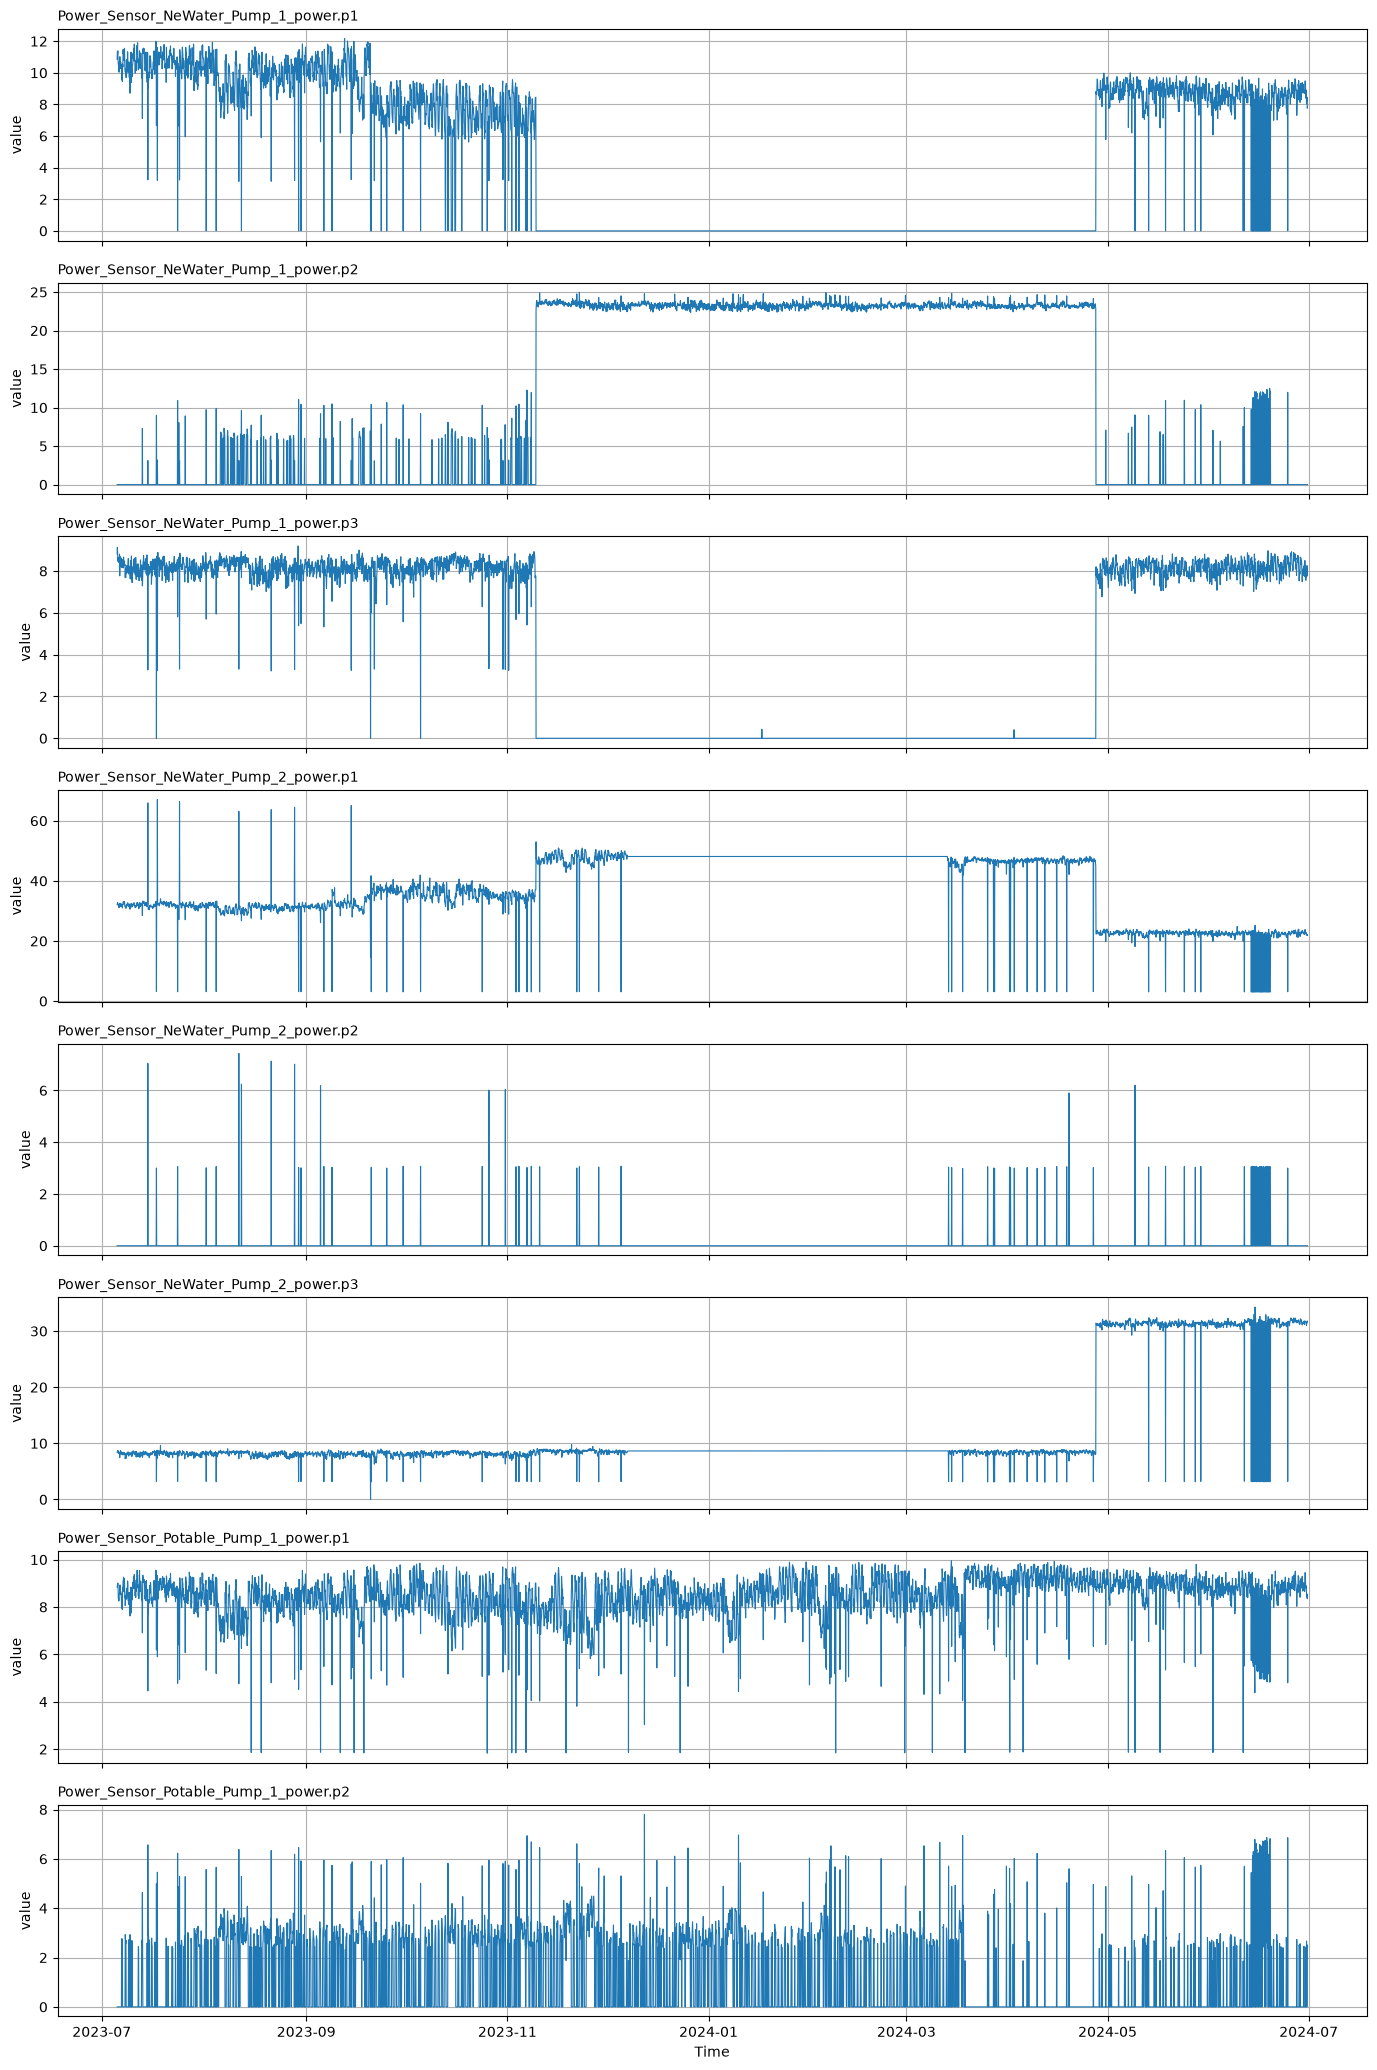

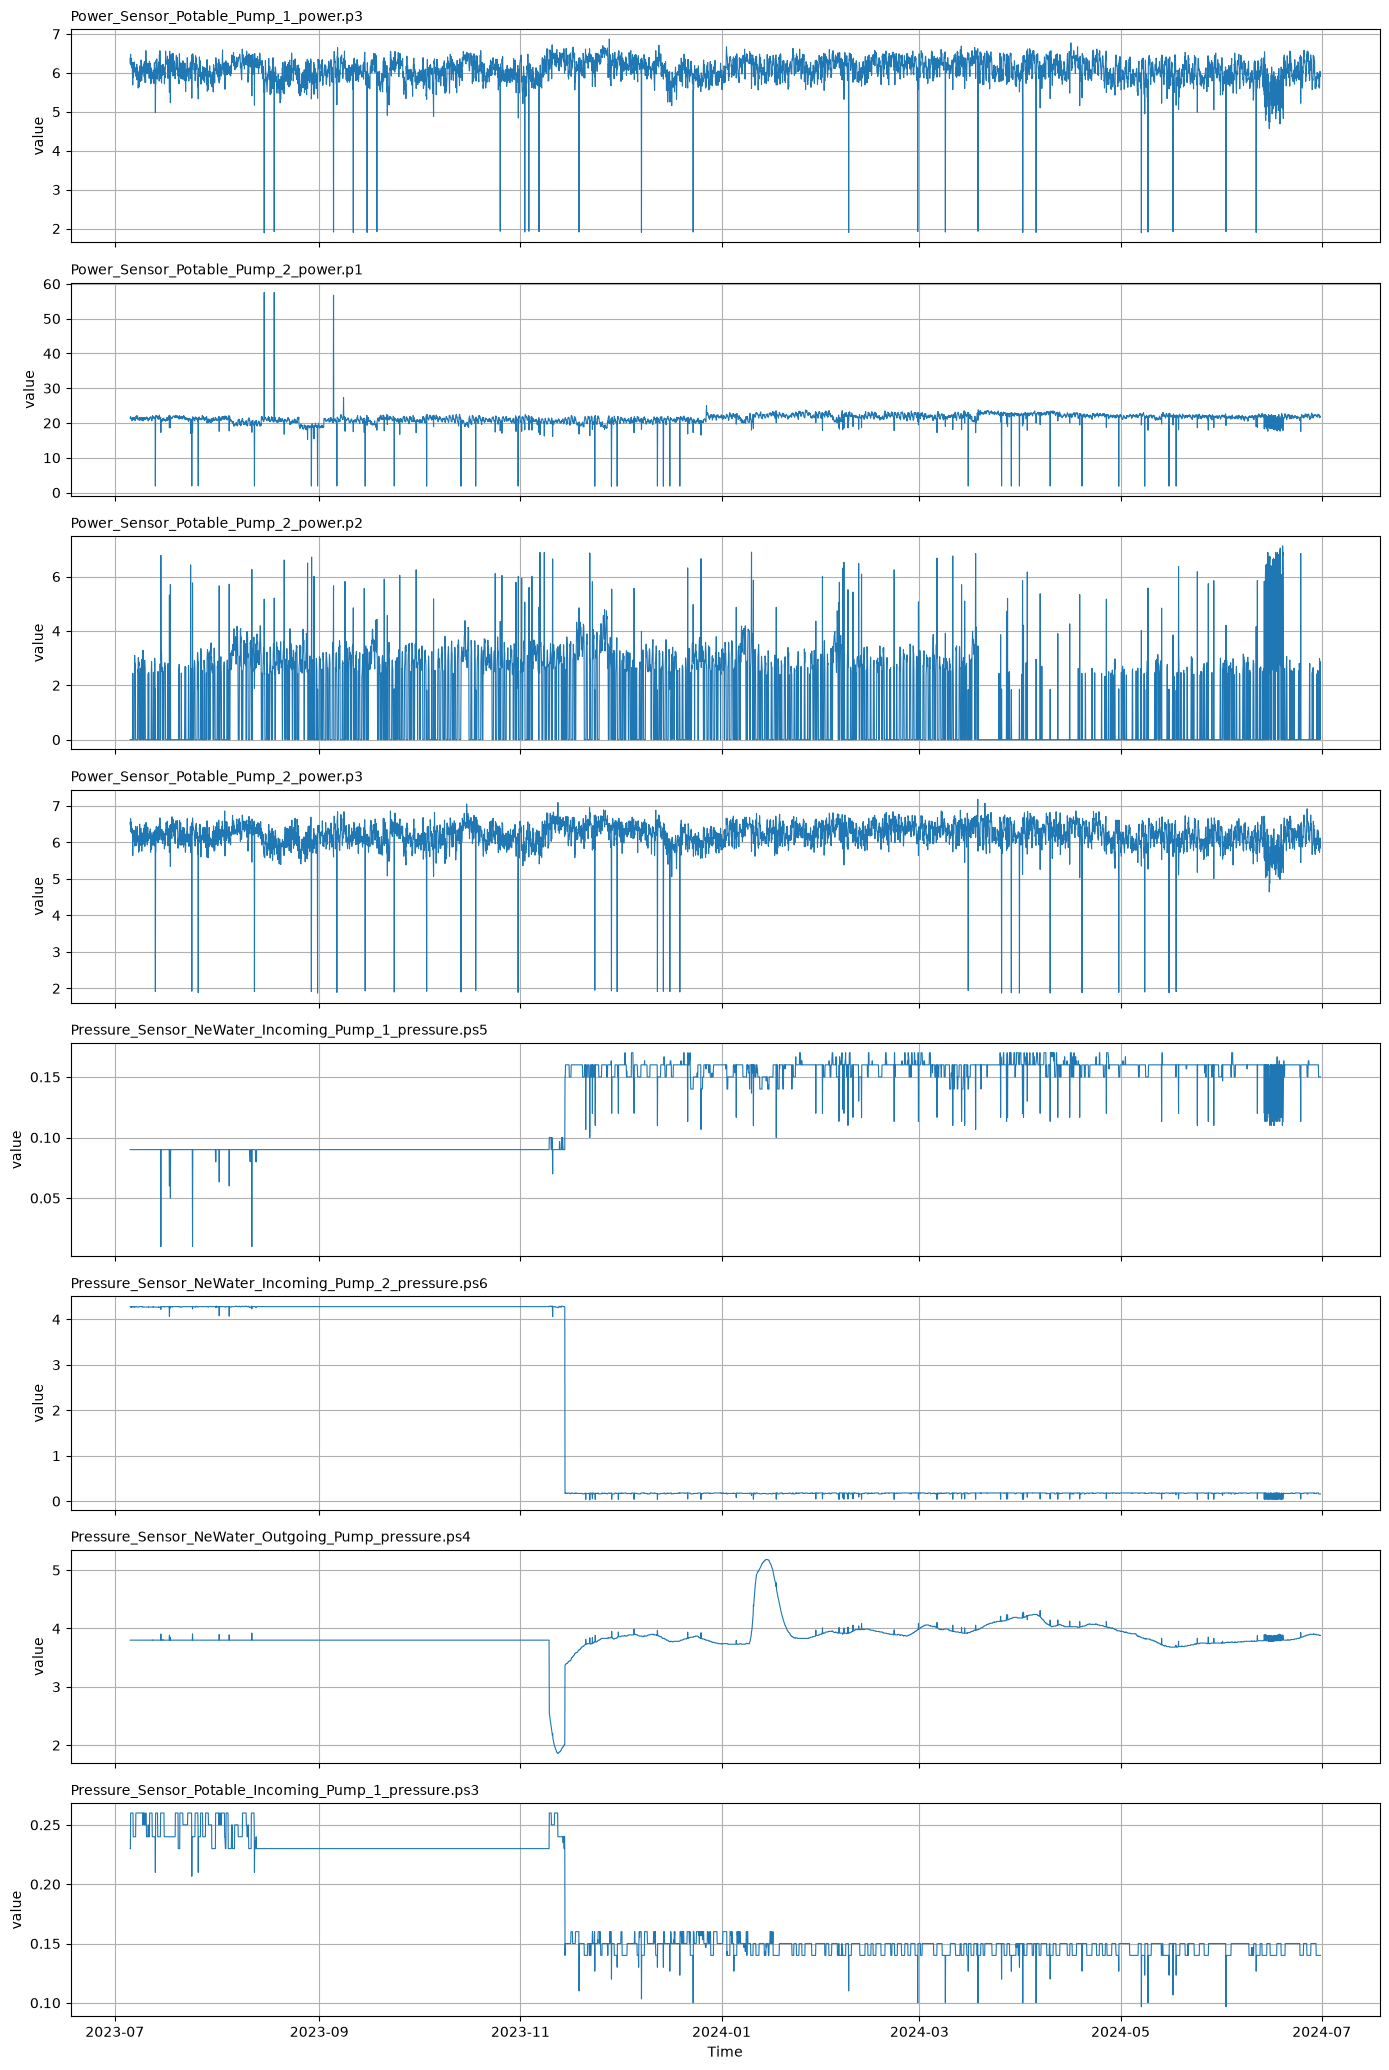

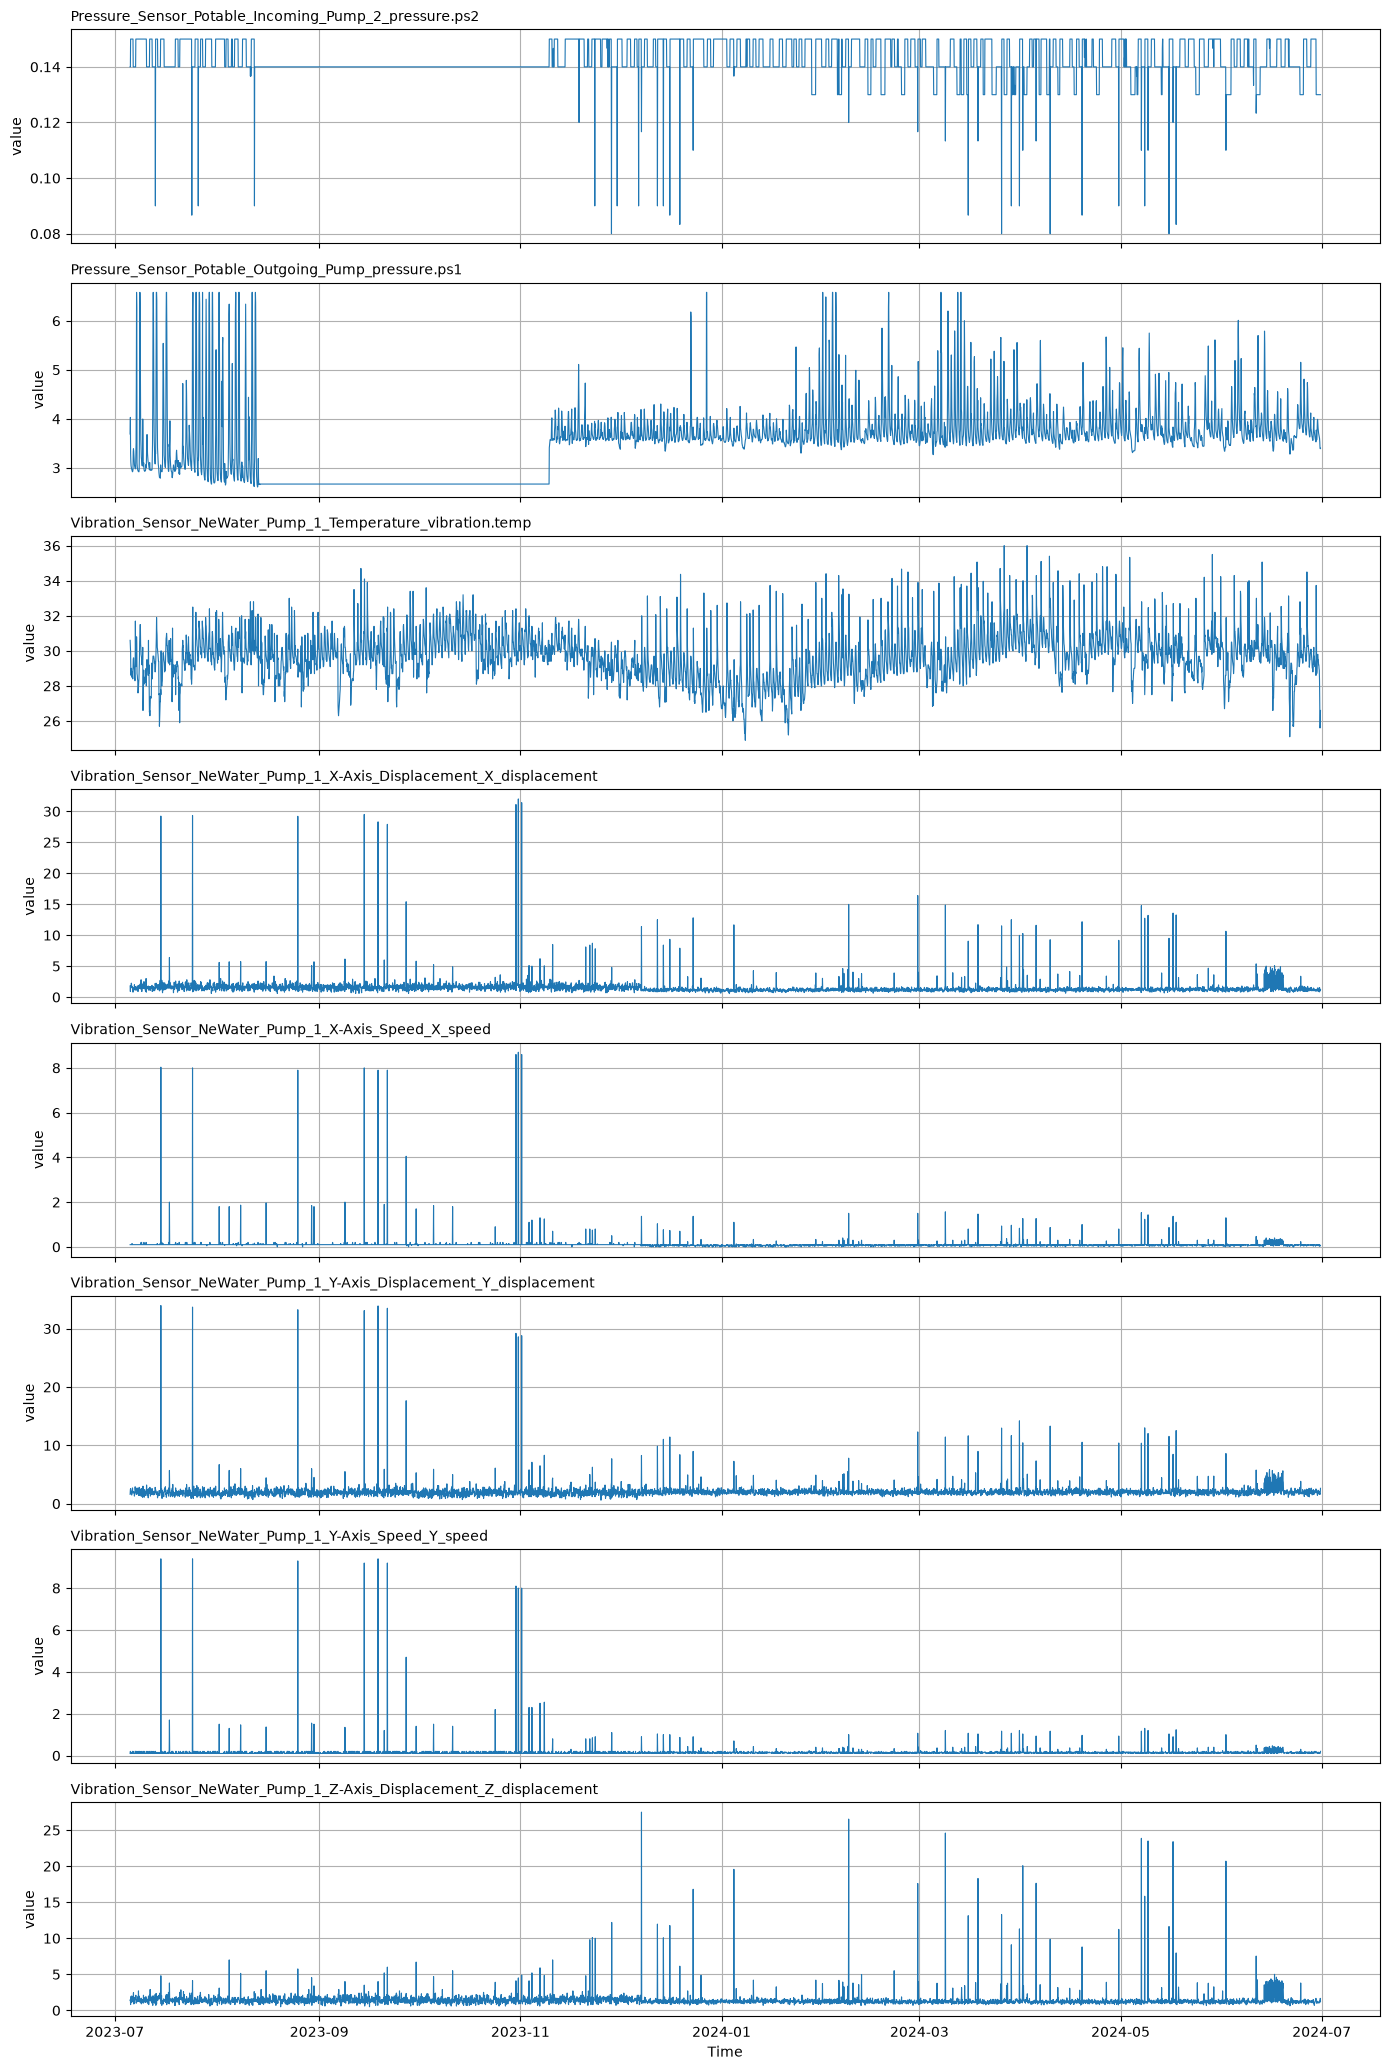

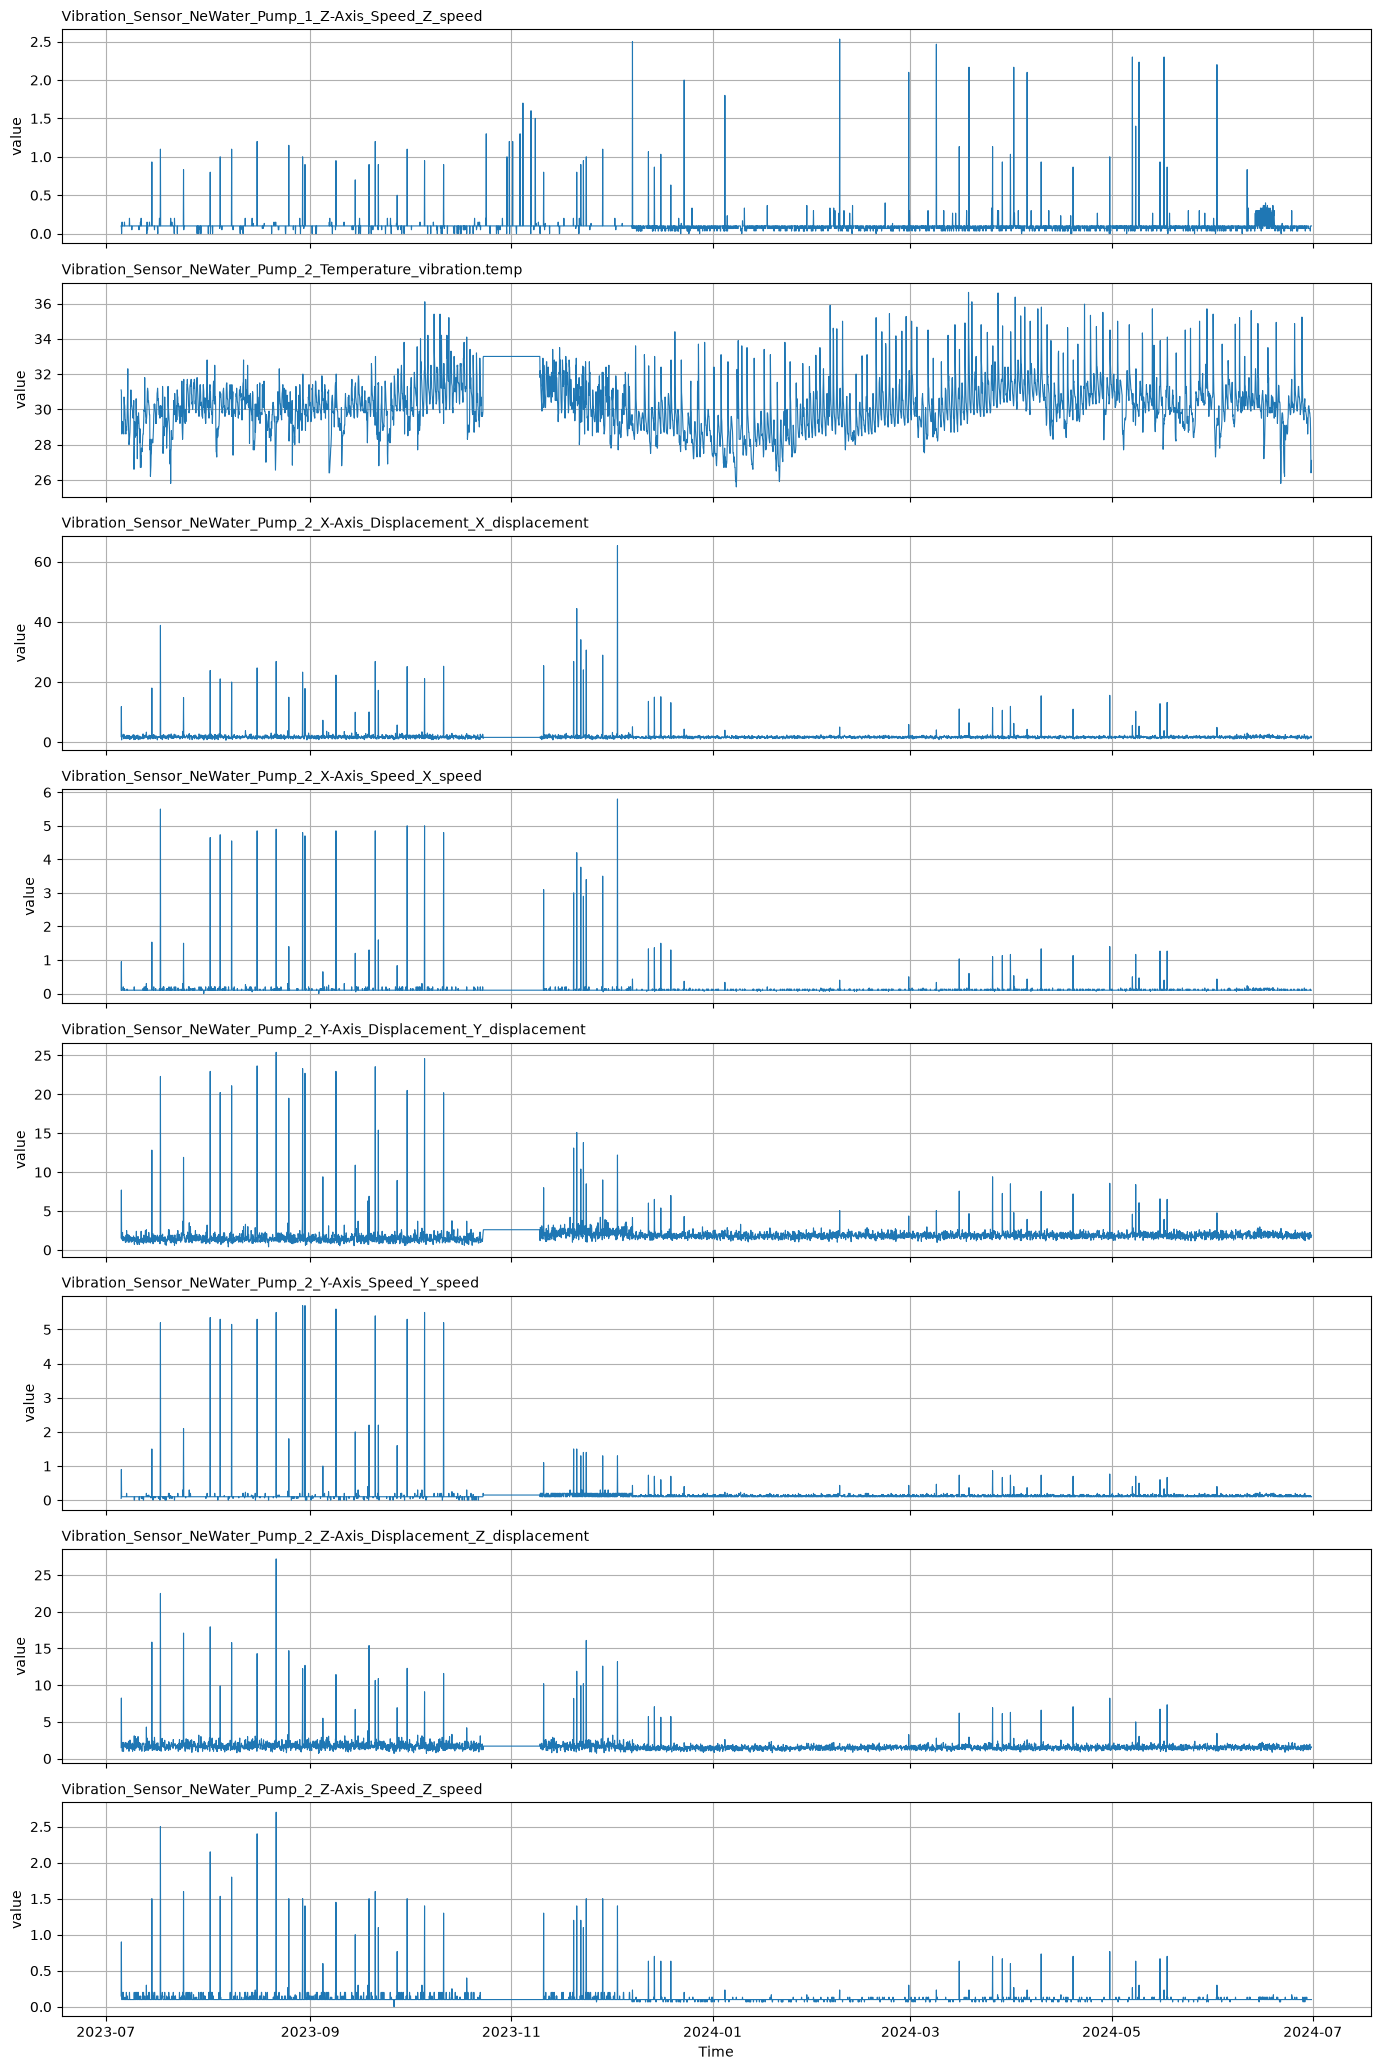

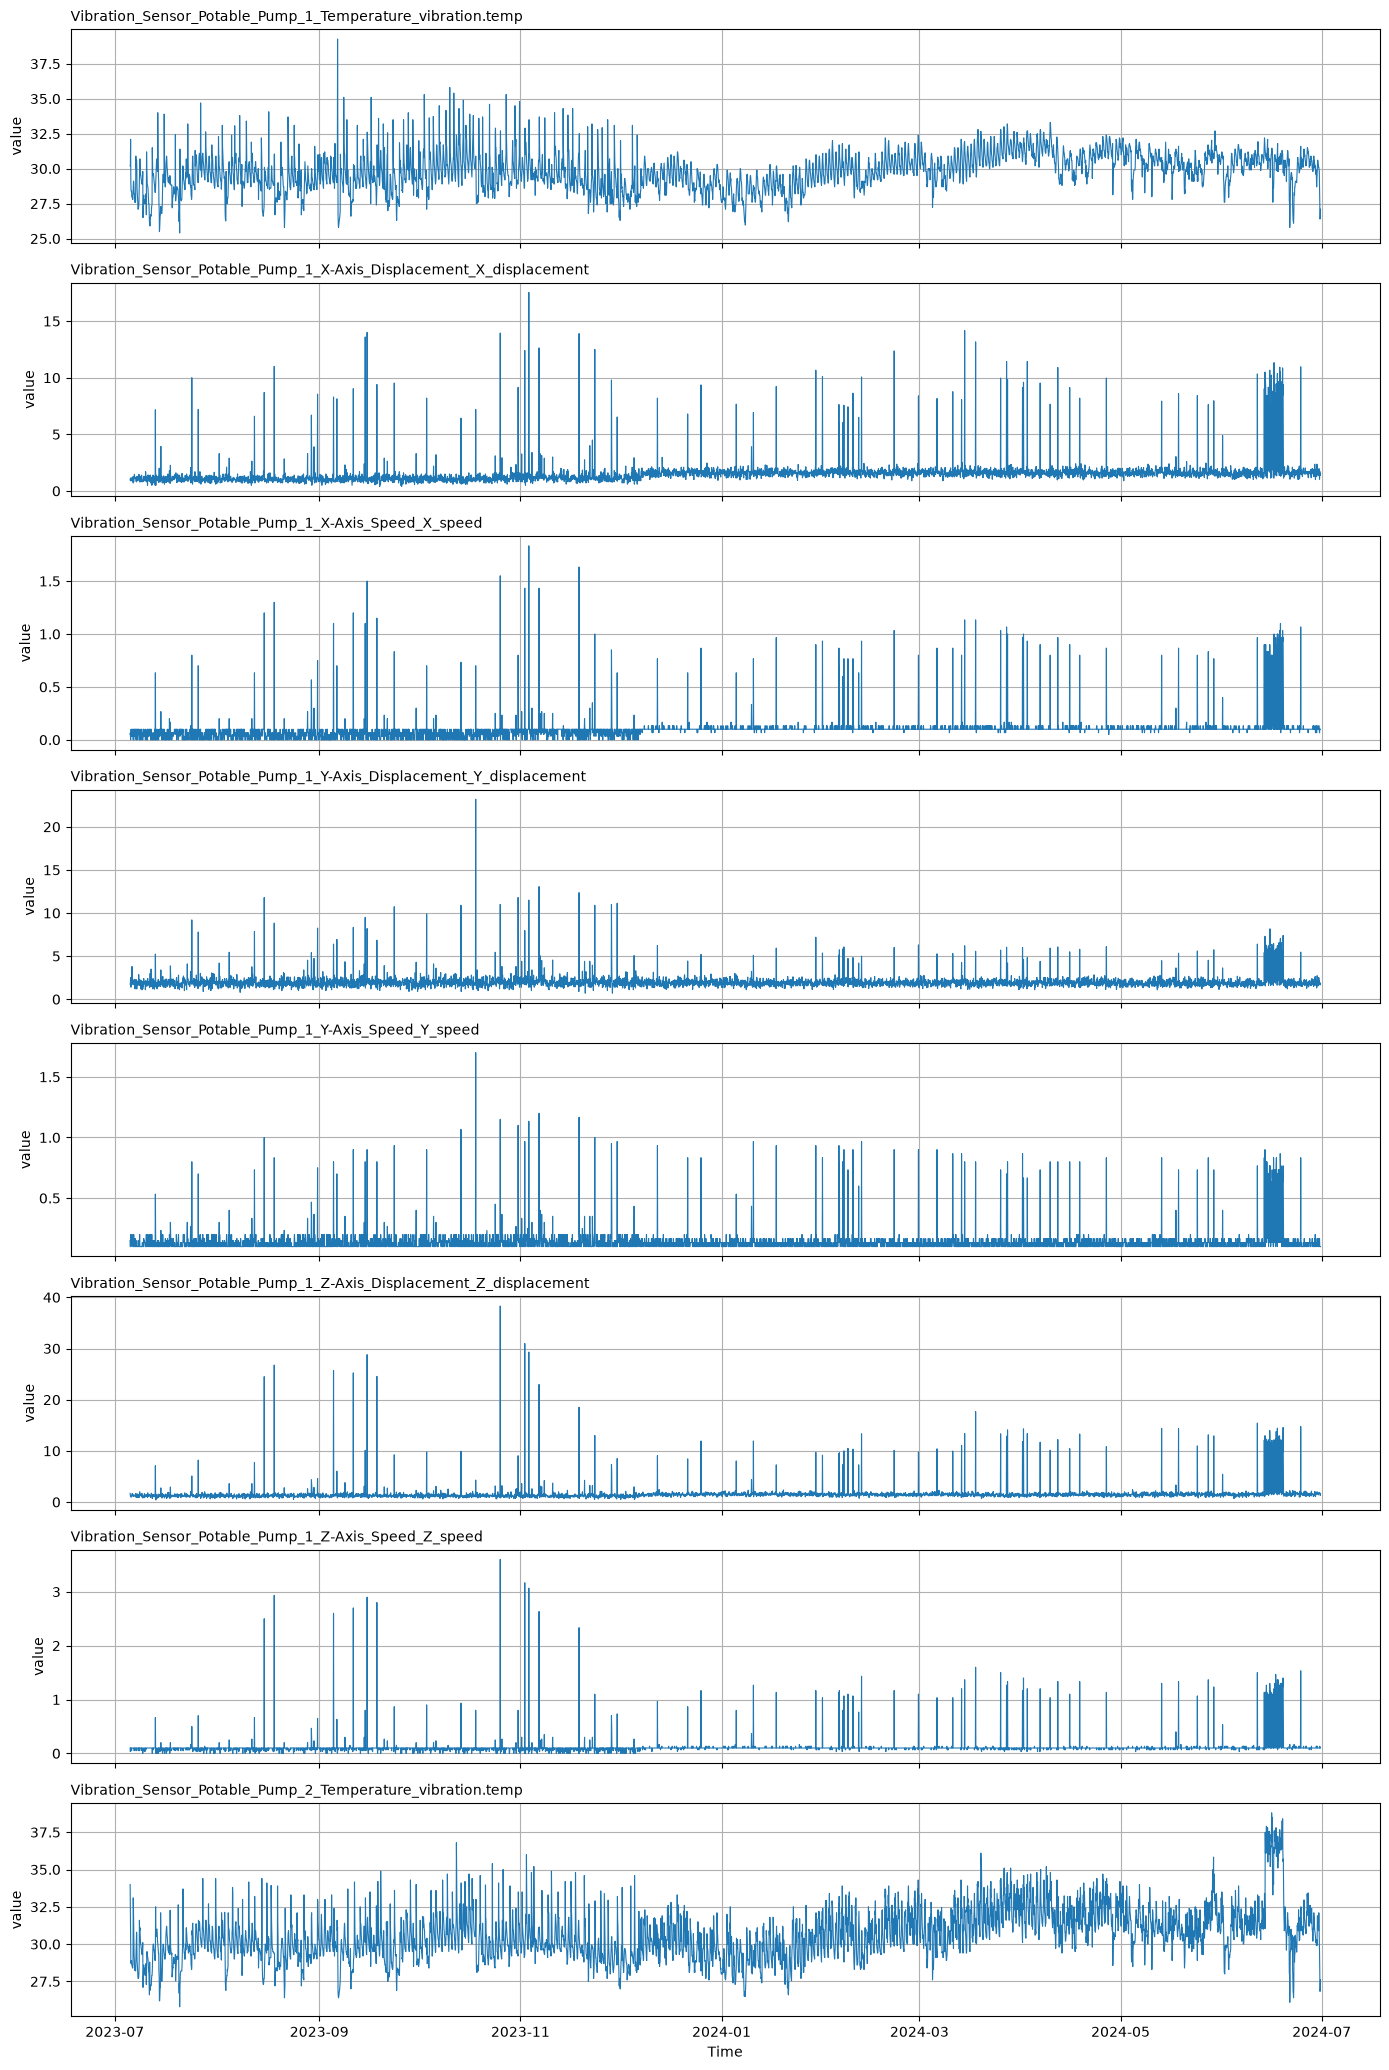

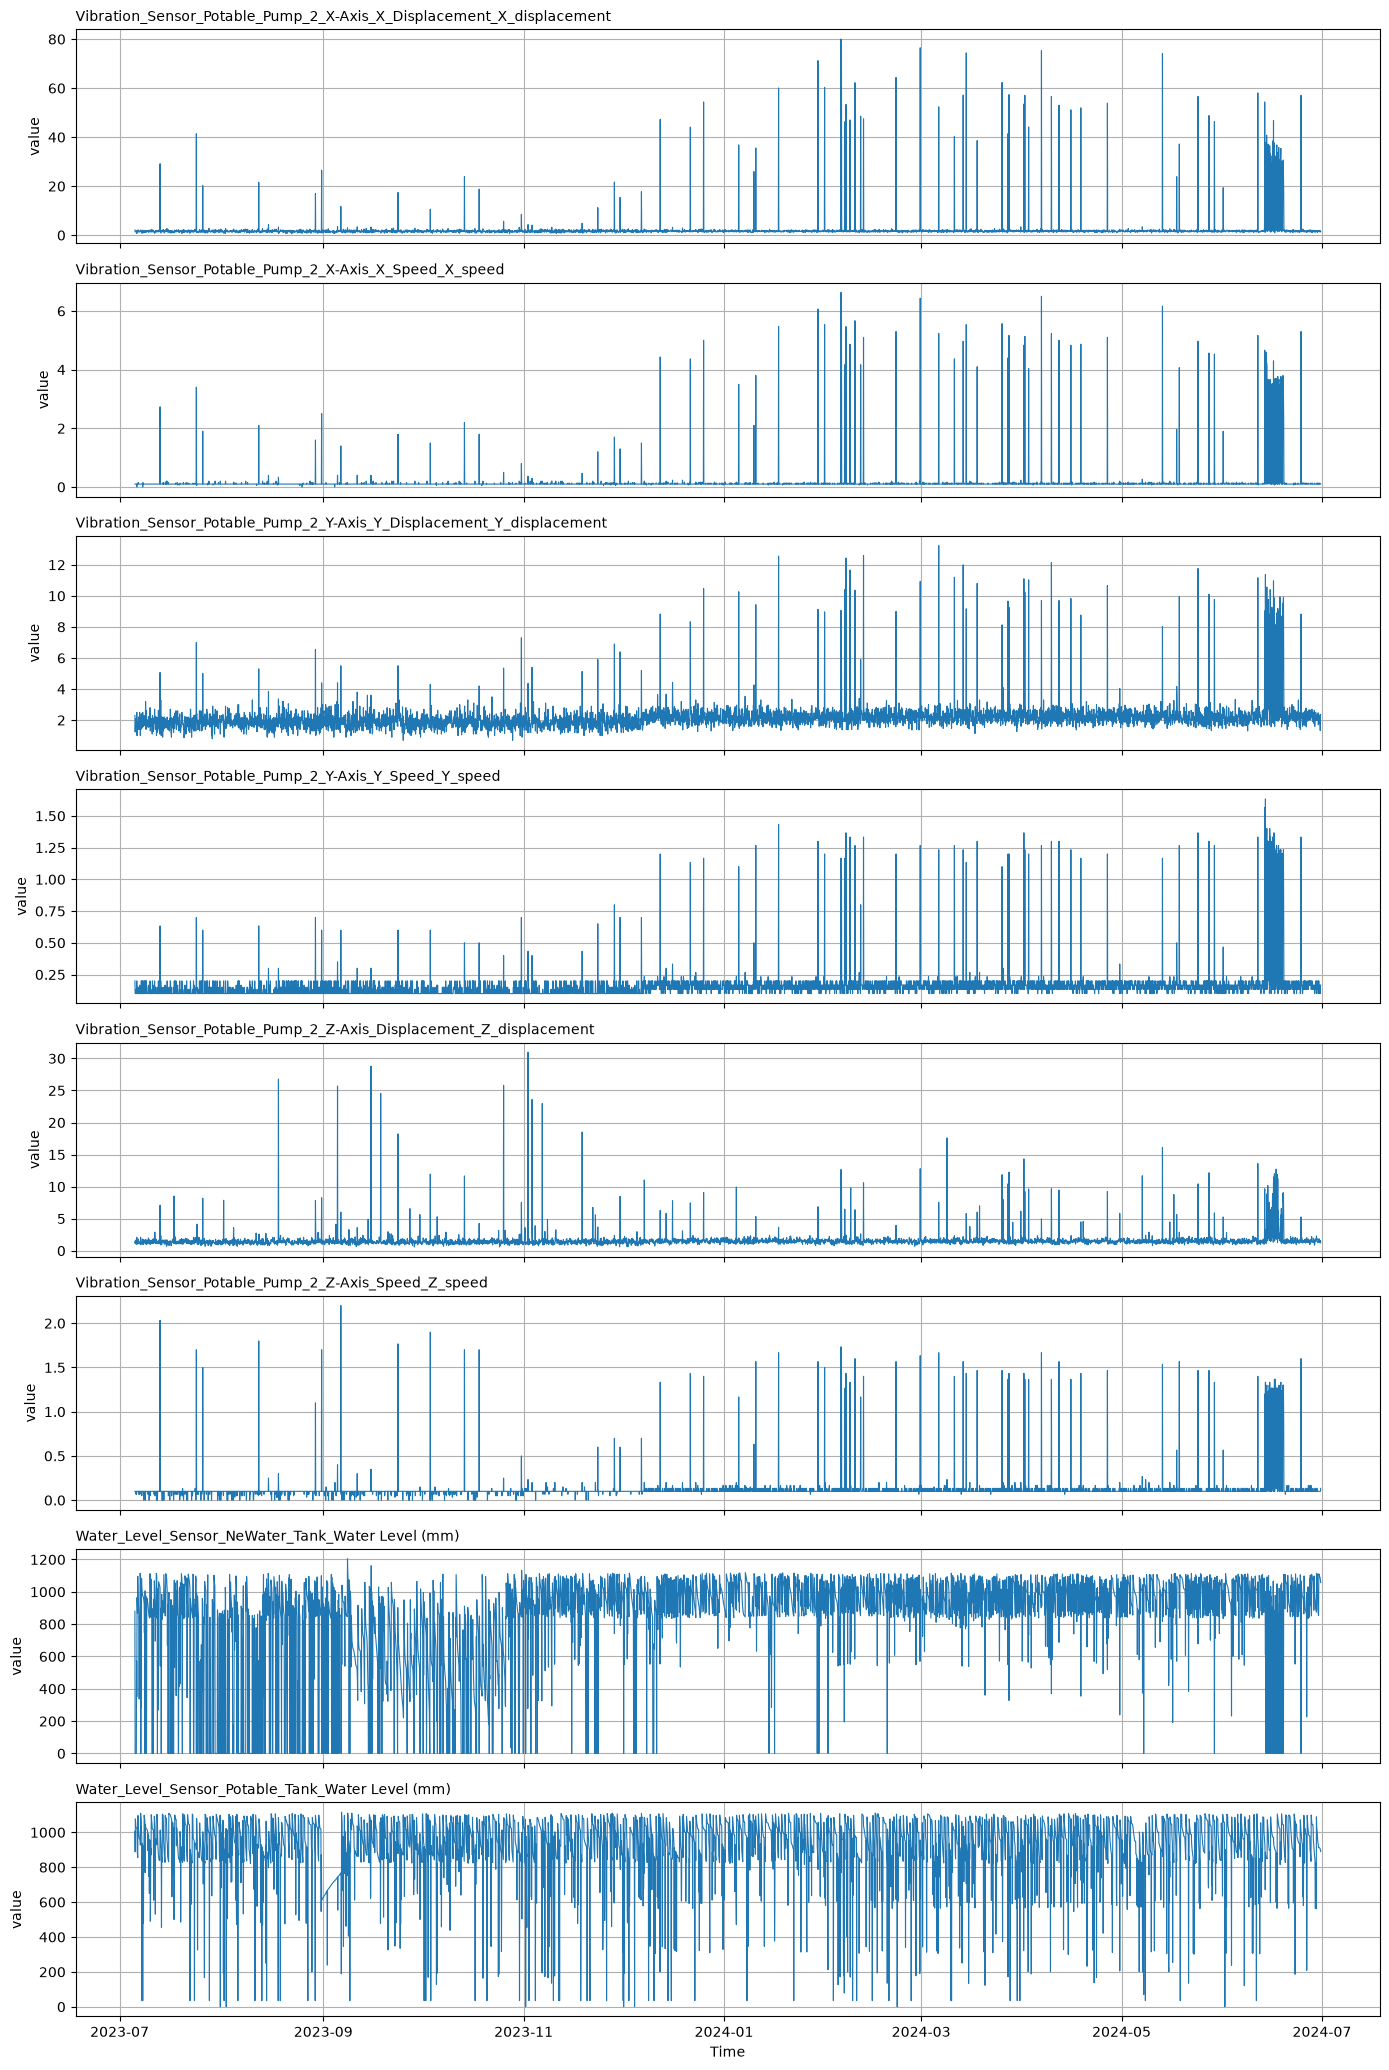

In [ ]:
MAX_POINTS_PER_SENSOR = 5_000
SENSORS_PER_FIGURE = 8


def display_sample(series: pd.Series, max_points: int = MAX_POINTS_PER_SENSOR) -> pd.Series:
    s = series.dropna()
    if len(s) <= max_points:
        return s
    step = int(np.ceil(len(s) / max_points))
    return s.iloc[::step]


for start in range(0, len(sensor_cols), SENSORS_PER_FIGURE):
    cols = sensor_cols[start:start + SENSORS_PER_FIGURE]
    fig, axes = plt.subplots(len(cols), 1, figsize=(14, 2.6 * len(cols)), sharex=True)
    if len(cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, cols):
        s = display_sample(df[col])
        ax.plot(s.index, s.values, linewidth=0.8)
        ax.set_title(col, loc="left", fontsize=10)
        ax.set_ylabel("value")

    axes[-1].set_xlabel("Time")
    fig.tight_layout()
    plt.show()

## Einzelnen Sensor groesser ansehen

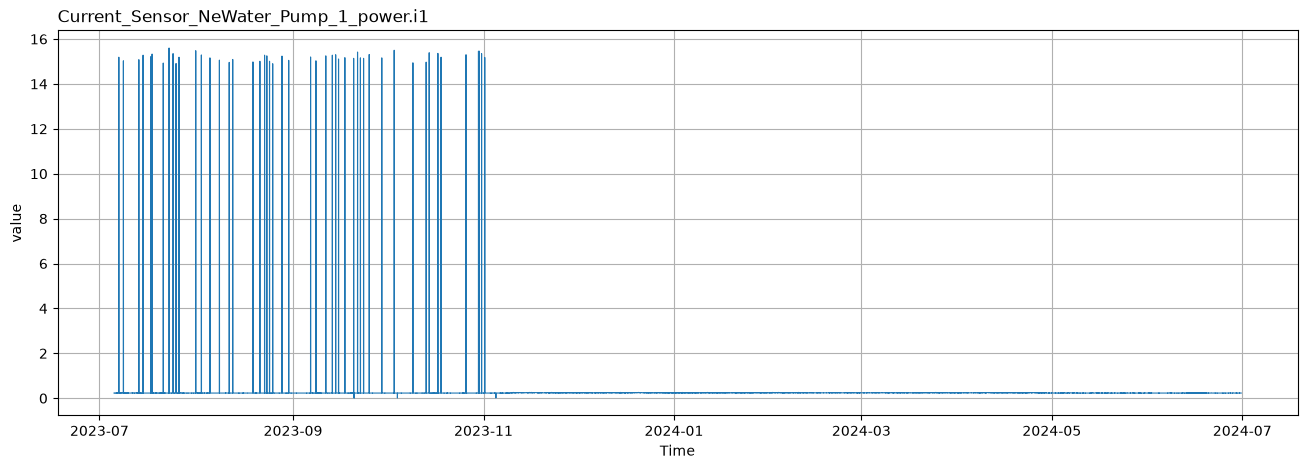

In [ ]:
SENSOR = sensor_cols[0]

s = display_sample(df[SENSOR], max_points=20_000)
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(s.index, s.values, linewidth=0.8)
ax.set_title(SENSOR, loc="left")
ax.set_xlabel("Time")
ax.set_ylabel("value")
plt.show()

## Target-Analyse

Prueft, ob `TARGET_COL` im geladenen DataFrame existiert, wie die Zielwerte verteilt sind, und sucht alternativ in Rohdaten-Headern sowie Metadaten nach Activity/Fault/Event/Label-Hinweisen.

In [ ]:
TARGET_COL = globals().get("TARGET_COL", globals().get("ACTIVITY_ID_COL", "activity_id"))
TARGET_KEYWORDS = ["activity", "label", "target", "fault", "event", "state", "class", "maintenance", "anomaly"]

print("TARGET_COL:", TARGET_COL)

if "df" in globals():
    print("df shape:", df.shape)
    exact_exists = TARGET_COL in df.columns
    candidate_cols = [
        col for col in df.columns
        if col == TARGET_COL or any(keyword in str(col).lower() for keyword in TARGET_KEYWORDS)
    ]

    print("target_col exists:", exact_exists)
    print("candidate target-like columns:", candidate_cols[:50])

    if exact_exists:
        target = df[TARGET_COL]
        print("dtype:", target.dtype)
        print("missing:", int(target.isna().sum()), "of", len(target))
        print("unique values:", target.nunique(dropna=False))

        display(target.to_frame().describe(include="all"))

        if target.nunique(dropna=False) <= 50:
            display(target.value_counts(dropna=False).rename("count").to_frame())
        elif pd.api.types.is_numeric_dtype(target):
            sampled = display_sample(target, max_points=20_000) if "display_sample" in globals() else target.dropna().iloc[::max(1, int(np.ceil(target.dropna().shape[0] / 20_000)))]
            fig, ax = plt.subplots(figsize=(16, 4))
            ax.plot(sampled.index, sampled.values, linewidth=0.8)
            ax.set_title(f"Target over time: {TARGET_COL}", loc="left")
            ax.set_xlabel("Time")
            ax.set_ylabel(TARGET_COL)
            plt.show()
    else:
        print("Hinweis: TARGET_COL ist nicht im DataFrame. Fuer Classification muss ein Label ggf. aus Metadaten-Zeitraeumen abgeleitet werden.")
else:
    print("Kein df im Notebook-Speicher gefunden. Fuehre zuerst die Daten-laden-Zelle aus, oder nutze den Metadaten/Header-Scan unten.")

# Raw headers and metadata scan.
metadata_matches = []
header_matches = []

for path in sorted(DATA_DIR.rglob("*")):
    if not path.is_file():
        continue

    suffix = path.suffix.lower()
    name_lower = path.name.lower()

    if suffix in {".md", ".json", ".jsonld", ".txt", ".csv", ".tsv"}:
        try:
            if suffix in {".txt", ".csv", ".tsv"}:
                with path.open("r", encoding="utf-8-sig", errors="ignore") as f:
                    first = f.readline().strip()
                    second = f.readline().strip()
                header = second if first.startswith("sep=") else first
                if any(keyword in header.lower() for keyword in TARGET_KEYWORDS) or TARGET_COL.lower() in header.lower():
                    header_matches.append((path.relative_to(DATA_DIR), header))
            else:
                text = path.read_text(encoding="utf-8", errors="ignore")
                for line_no, line in enumerate(text.splitlines(), start=1):
                    line_lower = line.lower()
                    if TARGET_COL.lower() in line_lower or any(keyword in line_lower for keyword in TARGET_KEYWORDS):
                        metadata_matches.append((path.relative_to(DATA_DIR), line_no, line.strip()))
        except Exception as exc:
            print("skip", path.relative_to(DATA_DIR), exc)

print("\nHeader matches:")
if header_matches:
    display(pd.DataFrame(header_matches, columns=["file", "header"]))
else:
    print("Keine target-/label-artigen Spaltennamen in Rohdaten-Headern gefunden.")

print("\nMetadata matches:")
if metadata_matches:
    display(pd.DataFrame(metadata_matches, columns=["file", "line", "text"]).head(80))
else:
    print("Keine target-/event-artigen Hinweise in Metadaten gefunden.")


TARGET_COL: activity_id
df shape: (519847, 73)
target_col exists: True
candidate target-like columns: ['activity_id']
dtype: int64
missing: 0 of 519847
unique values: 4


,activity_id
count,519847.000000
mean,0.421047
std,1.006897
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,3.000000


,count
activity_id,
0,437767
3,63360
2,10080
1,8640



Header matches:
Keine target-/label-artigen Spaltennamen in Rohdaten-Headern gefunden.

Metadata matches:


,file,line,text
0,Water_Pump_Dataset_for_a_Water_Supply_System/W...,244,| **Event Type** | **Event** | **Descrip...
1,Water_Pump_Dataset_for_a_Water_Supply_System/W...,246,| **System Maintenance** | Tank Washing | Drop...
2,Water_Pump_Dataset_for_a_Water_Supply_System/W...,247,| **Fault** | Hardware | PLC faile...
3,Water_Pump_Dataset_for_a_Water_Supply_System/W...,660,"""@value"": ""This dataset contains sensor data f..."
